In [137]:
#Libraries used for Data Preprocessing and Hyperparameter tuning
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [138]:
data = pd.read_csv("D:\DataProjects\WGU\Resources\churn_clean.csv")

In [139]:
#Viewing number of null values
data.isnull().sum().sum()

0

In [140]:
data.columns
#Removing Identifier information because we can just use indexes and we don't need it for the project
data = data.drop(columns = ['CaseOrder', 'Customer_id', 'Interaction', 'UID'])

In [141]:
#Printing whether column is numeric or categorical
for i in data.columns:
    if data[i].dtype == 'object':
        print(i,'Categorical')
    else:
        print(i,'Numerical')

City Categorical
State Categorical
County Categorical
Zip Numerical
Lat Numerical
Lng Numerical
Population Numerical
Area Categorical
TimeZone Categorical
Job Categorical
Children Numerical
Age Numerical
Income Numerical
Marital Categorical
Gender Categorical
Churn Categorical
Outage_sec_perweek Numerical
Email Numerical
Contacts Numerical
Yearly_equip_failure Numerical
Techie Categorical
Contract Categorical
Port_modem Categorical
Tablet Categorical
InternetService Categorical
Phone Categorical
Multiple Categorical
OnlineSecurity Categorical
OnlineBackup Categorical
DeviceProtection Categorical
TechSupport Categorical
StreamingTV Categorical
StreamingMovies Categorical
PaperlessBilling Categorical
PaymentMethod Categorical
Tenure Numerical
MonthlyCharge Numerical
Bandwidth_GB_Year Numerical
Item1 Numerical
Item2 Numerical
Item3 Numerical
Item4 Numerical
Item5 Numerical
Item6 Numerical
Item7 Numerical
Item8 Numerical


## Seperating the dataset into three sections

    1 will contain customer demographic and location data

    1 will contain the contract information of the customer

    1 will contain all the survey responses from the customer

### All datasets will be designed to achieve the goal of accurately predicting churn using a KNN algorithm. I will select the one with the highest accuracy to move forward in analysis.

In [142]:
demo_cols = ['City', 'State', 'County', 'Zip', 'Lat', 'Lng', 'Population',
             'Area', 'TimeZone', 'Job', 'Children', 'Age', 'Income', 'Marital',
             'Gender', 'Churn']

service_cols = ['Outage_sec_perweek', 'Email', 'Contacts',
                'Yearly_equip_failure', 'Techie', 'Contract',
                'Port_modem', 'Tablet', 'InternetService', 'Phone',
                'Multiple', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
                'PaymentMethod', 'Tenure', 'MonthlyCharge','Bandwidth_GB_Year','Churn']

survey_cols = [ 'Item1','Item2', 'Item3', 'Item4', 'Item5',
               'Item6', 'Item7', 'Item8','Churn']

#Same process with all three variables filtering to include specified columns
demo = data.loc[:,demo_cols].copy(deep = True)

services = data.loc[:,service_cols].copy(deep = True)

survey = data.loc[:,survey_cols].copy(deep = True)

## Describing datasets 

### Dropping Categorical Columns with more than 20 values to ease the dummy variable creation process

In [143]:
def describe_df(df):
    #Describing the demo dataset for variable preprocessing
    for i in df.columns:
        if df[i].dtype == 'object':
            print(i,len(df[i].unique()))
            if len(df[i].unique()) > 20:
                print(f'Dropping {i}')
                df = df.drop(columns = i)
    #Printing number of columns after column removal
    print('Number of Columns',len(df.columns))
    print(df.describe())
    return df

In [144]:
demo = describe_df(demo)

City 6058
Dropping City
State 52
Dropping State
County 1620
Dropping County
Area 3
TimeZone 25
Dropping TimeZone
Job 639
Dropping Job
Marital 5
Gender 3
Churn 2
Number of Columns 11
                Zip           Lat           Lng     Population    Children  \
count  10000.000000  10000.000000  10000.000000   10000.000000  10000.0000   
mean   49153.319600     38.757567    -90.782536    9756.562400      2.0877   
std    27532.196108      5.437389     15.156142   14432.698671      2.1472   
min      601.000000     17.966120   -171.688150       0.000000      0.0000   
25%    26292.500000     35.341828    -97.082812     738.000000      0.0000   
50%    48869.500000     39.395800    -87.918800    2910.500000      1.0000   
75%    71866.500000     42.106908    -80.088745   13168.000000      3.0000   
max    99929.000000     70.640660    -65.667850  111850.000000     10.0000   

                Age         Income  
count  10000.000000   10000.000000  
mean      53.078400   39806.926771  
std 

In [145]:
services = describe_df(services)

Techie 2
Contract 3
Port_modem 2
Tablet 2
InternetService 3
Phone 2
Multiple 2
OnlineSecurity 2
OnlineBackup 2
DeviceProtection 2
TechSupport 2
StreamingTV 2
StreamingMovies 2
PaperlessBilling 2
PaymentMethod 4
Churn 2
Number of Columns 23
       Outage_sec_perweek         Email      Contacts  Yearly_equip_failure  \
count        10000.000000  10000.000000  10000.000000          10000.000000   
mean            10.001848     12.016000      0.994200              0.398000   
std              2.976019      3.025898      0.988466              0.635953   
min              0.099747      1.000000      0.000000              0.000000   
25%              8.018214     10.000000      0.000000              0.000000   
50%             10.018560     12.000000      1.000000              0.000000   
75%             11.969485     14.000000      2.000000              1.000000   
max             21.207230     23.000000      7.000000              6.000000   

             Tenure  MonthlyCharge  Bandwidth_GB

In [146]:
survey = describe_df(survey)

Churn 2
Number of Columns 9
              Item1         Item2         Item3         Item4         Item5  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       3.490800      3.505100      3.487000      3.497500      3.492900   
std        1.037797      1.034641      1.027977      1.025816      1.024819   
min        1.000000      1.000000      1.000000      1.000000      1.000000   
25%        3.000000      3.000000      3.000000      3.000000      3.000000   
50%        3.000000      4.000000      3.000000      3.000000      3.000000   
75%        4.000000      4.000000      4.000000      4.000000      4.000000   
max        7.000000      7.000000      8.000000      7.000000      7.000000   

              Item6         Item7         Item8  
count  10000.000000  10000.000000  10000.000000  
mean       3.497300      3.509500      3.495600  
std        1.033586      1.028502      1.028633  
min        1.000000      1.000000      1.000000  
25%       

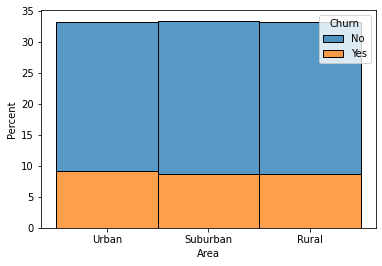

Area      Churn
Rural     No       2464
          Yes       863
Suburban  No       2473
          Yes       873
Urban     No       2413
          Yes       914
Name: Churn, dtype: int64


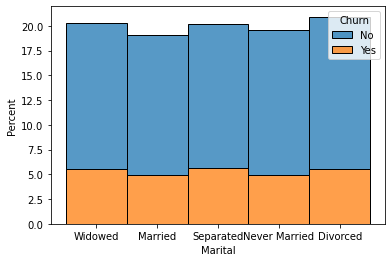

Marital        Churn
Divorced       No       1539
               Yes       553
Married        No       1418
               Yes       493
Never Married  No       1468
               Yes       488
Separated      No       1454
               Yes       560
Widowed        No       1471
               Yes       556
Name: Churn, dtype: int64


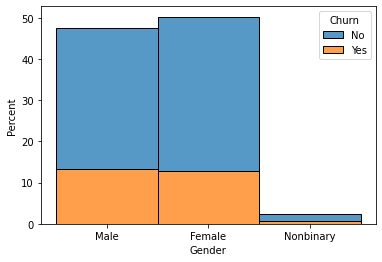

Gender     Churn
Female     No       3753
           Yes      1272
Male       No       3425
           Yes      1319
Nonbinary  No        172
           Yes        59
Name: Churn, dtype: int64


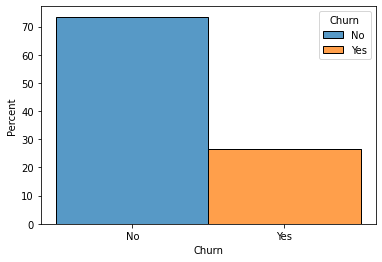

Churn  Churn
No     No       7350
Yes    Yes      2650
Name: Churn, dtype: int64


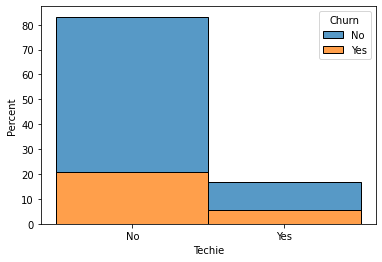

Techie  Churn
No      No       6226
        Yes      2095
Yes     No       1124
        Yes       555
Name: Churn, dtype: int64


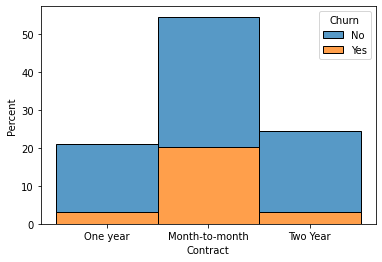

Contract        Churn
Month-to-month  No       3422
                Yes      2034
One year        No       1795
                Yes       307
Two Year        No       2133
                Yes       309
Name: Churn, dtype: int64


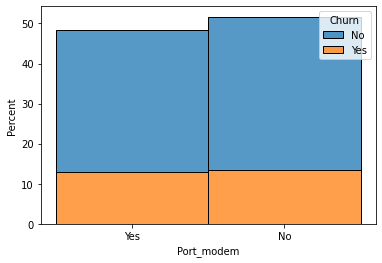

Port_modem  Churn
No          No       3815
            Yes      1351
Yes         No       3535
            Yes      1299
Name: Churn, dtype: int64


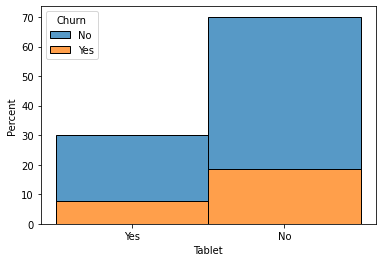

Tablet  Churn
No      No       5146
        Yes      1863
Yes     No       2204
        Yes       787
Name: Churn, dtype: int64


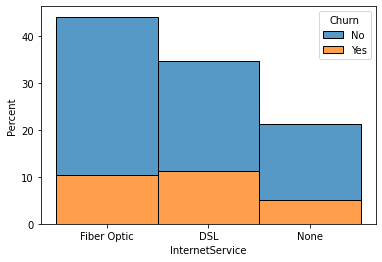

InternetService  Churn
DSL              No       2349
                 Yes      1114
Fiber Optic      No       3368
                 Yes      1040
None             No       1633
                 Yes       496
Name: Churn, dtype: int64


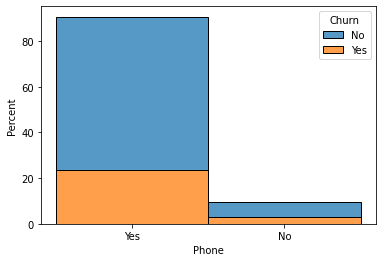

Phone  Churn
No     No        652
       Yes       281
Yes    No       6698
       Yes      2369
Name: Churn, dtype: int64


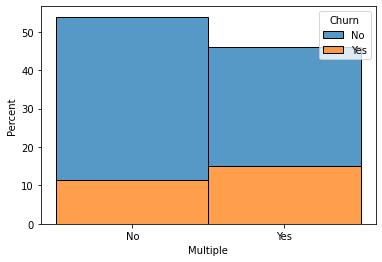

Multiple  Churn
No        No       4253
          Yes      1139
Yes       No       3097
          Yes      1511
Name: Churn, dtype: int64


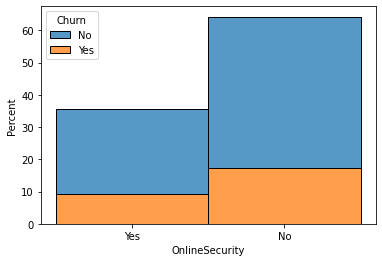

OnlineSecurity  Churn
No              No       4693
                Yes      1731
Yes             No       2657
                Yes       919
Name: Churn, dtype: int64


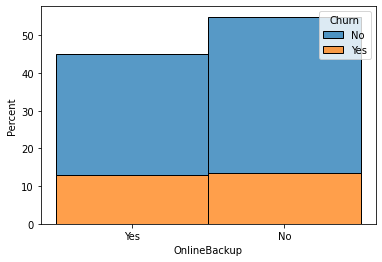

OnlineBackup  Churn
No            No       4149
              Yes      1345
Yes           No       3201
              Yes      1305
Name: Churn, dtype: int64


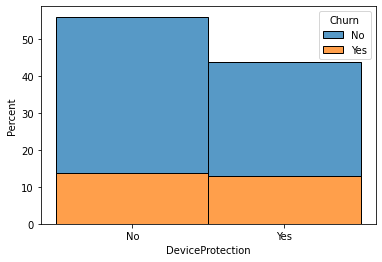

DeviceProtection  Churn
No                No       4250
                  Yes      1364
Yes               No       3100
                  Yes      1286
Name: Churn, dtype: int64


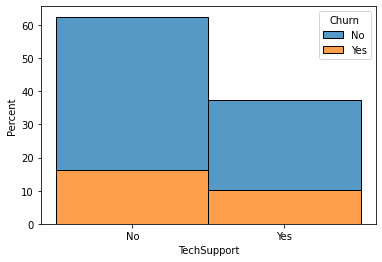

TechSupport  Churn
No           No       4634
             Yes      1616
Yes          No       2716
             Yes      1034
Name: Churn, dtype: int64


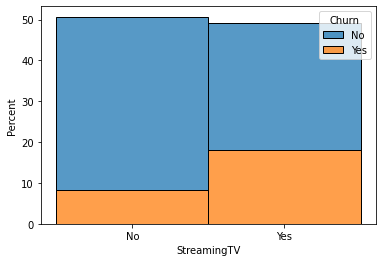

StreamingTV  Churn
No           No       4235
             Yes       836
Yes          No       3115
             Yes      1814
Name: Churn, dtype: int64


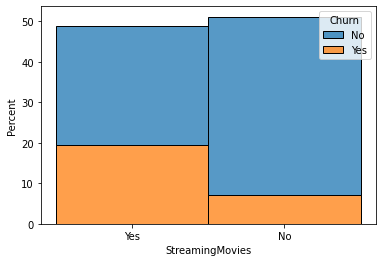

StreamingMovies  Churn
No               No       4394
                 Yes       716
Yes              No       2956
                 Yes      1934
Name: Churn, dtype: int64


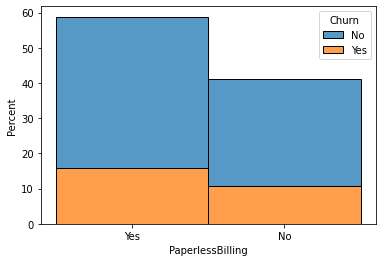

PaperlessBilling  Churn
No                No       3042
                  Yes      1076
Yes               No       4308
                  Yes      1574
Name: Churn, dtype: int64


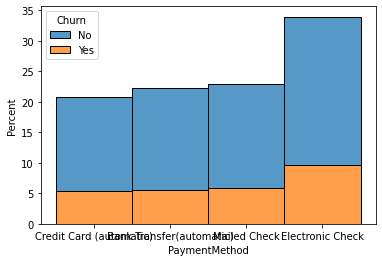

PaymentMethod             Churn
Bank Transfer(automatic)  No       1671
                          Yes       558
Credit Card (automatic)   No       1543
                          Yes       540
Electronic Check          No       2435
                          Yes       963
Mailed Check              No       1701
                          Yes       589
Name: Churn, dtype: int64


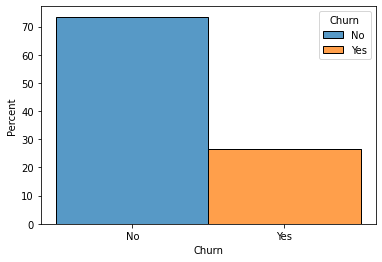

Churn  Churn
No     No       7350
Yes    Yes      2650
Name: Churn, dtype: int64


In [147]:
for cols in [demo.columns,services.columns]:
    for col in cols:
        if data[col].dtype == 'object':
            sns.histplot(data = data, x = col, hue = 'Churn',stat = 'percent',
                         discrete = True, common_norm = True, multiple = 'stack')
            plt.show()
            print((data.groupby([col])['Churn'].value_counts()))

## Preprocessing

Cleaning up Categorical Data
    
    1. Applying Ordinal Encoding to categorical data
    2. Getting dummy variables for each dataset

### Creating a pipeline to train a KNN model with optimal hyperparameters for each  dataset

Pipeline Process
    
    1. Applying StandardScaler to ALL data in the dataset
    2. GridSearchCV for model optimization

Pipeline will have to be fit 3 seperate times because each dataset has different variables

Model Selection

    Model Selection will be focused on two metrics, Precision and AUC score

In [148]:
#Cleaning up Categorical Data
def clean_categories(df):
    for i in df.columns:
        if (len(df[i].unique()) == 2) & (df[i].dtype =='object'):
            df[i] = df[i].map({'Yes':1,'No':0})
    return pd.get_dummies(df,drop_first = False)
demo = clean_categories(demo)
services = clean_categories(services)
survey = clean_categories(survey)

In [149]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [150]:
#Creating Pipeline for data subset selection process
def pipe(df):
    #Finds all columns that are not Churn
    X = [col for col in df.columns if col != 'Churn']
    #Filters dataframe to X predictors and y response 
    X = df.loc[:,X]
    y = df.loc[:,'Churn']
    
    steps = [('scaler',StandardScaler()),('knn',KNeighborsClassifier())]

    pipeline = Pipeline(steps)

    params = {'knn__n_neighbors': np.arange(5,50)}

    X_train,X_test, y_train, y_test = train_test_split(X,y,
                                                   test_size = .2,random_state = 1000,stratify = y)

    cv = GridSearchCV(pipeline,param_grid = params,n_jobs = -1,scoring = 'accuracy')
    
    cv.fit(X_train,y_train)
    
    return(X_train,y_train,X_test,y_test,cv)

In [151]:
demo_results = pipe(demo)
services_results = pipe(services)
survey_results = pipe(survey)

In [152]:
print('Demographics',demo_results[4].best_score_)
print('Demographics',demo_results[4].best_params_)
print('Services',services_results[4].best_score_)
print('Services',services_results[4].best_params_)
print('Survey',survey_results[4].best_score_)
print('Survey',survey_results[4].best_params_)

Demographics 0.7354999999999998
Demographics {'knn__n_neighbors': 41}
Services 0.8747499999999999
Services {'knn__n_neighbors': 23}
Survey 0.7351249999999999
Survey {'knn__n_neighbors': 34}


### Data regarding contract structure and services are clearly much more accurate in predicting churn using variable proximity. We may be able to use some of the variables from the other datasets to boost accuracy, but this is outside of the scope of my project.

In [153]:
# Selecting services dataset as my analytical focus
services

,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Techie,Port_modem,Tablet,Phone,Multiple,OnlineSecurity,...,Contract_Month-to-month,Contract_One year,Contract_Two Year,InternetService_DSL,InternetService_Fiber Optic,InternetService_None,PaymentMethod_Bank Transfer(automatic),PaymentMethod_Credit Card (automatic),PaymentMethod_Electronic Check,PaymentMethod_Mailed Check
0,7.978323,10,0,1,0,1,1,1,0,1,...,0,1,0,0,1,0,0,1,0,0
1,11.699080,12,0,1,1,0,1,1,1,1,...,1,0,0,0,1,0,1,0,0,0
2,10.752800,9,0,1,1,1,0,1,1,0,...,0,0,1,1,0,0,0,1,0,0
3,14.913540,15,2,0,1,0,0,1,0,1,...,0,0,1,1,0,0,0,0,0,1
4,8.147417,16,2,1,0,1,0,0,0,0,...,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9.415935,12,2,0,0,1,1,1,1,0,...,1,0,0,1,0,0,0,0,1,0
9996,6.740547,15,2,0,0,0,0,1,1,1,...,0,0,1,0,1,0,0,0,1,0
9997,6.590911,10,0,0,0,0,0,1,1,1,...,1,0,0,0,1,0,1,0,0,0
9998,12.071910,14,1,0,0,0,1,0,1,0,...,0,0,1,0,1,0,0,1,0,0


In [154]:
#Aggregating the training and test data into seperate csv files
X_train, y_train, X_test, y_test = services_results[:4]

#This aggregation is purely for data exportation and some data exploration in later steps
train = X_train
train['Churn'] = y_train
test = X_test
test['Churn'] = y_test

#Exporting datasets
test.to_csv('D:\\DataProjects\\WGU\\Data Mining I\\task_1_test.csv')
train.to_csv('D:\\DataProjects\\WGU\\Data Mining I\\task_1_training.csv')

#Clearing some memory for next steps
#del demo
#del survey
#del demo_results
#del survey_results

In [171]:
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_score
#Create different KNN algorithms with little tweaks in the n_neighbors parameter
testing = [5,10,15,19,20,21,25,30,35,49]


def classify_fit_prob(X_train, y_train, X_test,y_test, n_neighbors):
    KNN = KNeighborsClassifier(n_neighbors = n_neighbors,n_jobs = -1)
    KNN.fit(X_train.drop(columns='Churn'),y_train)
    score = cross_val_score(estimator = KNN,X = X_test,y = y_test,scoring = 'roc_auc',cv = 5).mean()
    y_pred_prob = KNN.predict_proba(X_test.drop(columns = 'Churn'))[:,1]
    return score
    
for i in testing:
    roc_auc = classify_fit_prob(X_train,y_train,X_test,y_test,i)
    print(f'Number of Neighbors: {i}')
    print(f'Area Under Curve: {round(roc_auc,3)}')

Number of Neighbors: 5
Area Under Curve: 0.835
Number of Neighbors: 10
Area Under Curve: 0.85
Number of Neighbors: 15
Area Under Curve: 0.85
Number of Neighbors: 19
Area Under Curve: 0.853
Number of Neighbors: 20
Area Under Curve: 0.856
Number of Neighbors: 21
Area Under Curve: 0.856
Number of Neighbors: 25
Area Under Curve: 0.855
Number of Neighbors: 30
Area Under Curve: 0.856
Number of Neighbors: 35
Area Under Curve: 0.854
Number of Neighbors: 49
Area Under Curve: 0.847


### Selecting 20 neighbors as our tuned model hyperparameter

In [215]:
#Training the optimal model
model =  KNeighborsClassifier(n_neighbors = 20,n_jobs = -1)
model.fit(X_train.drop(columns = ['Churn']),y_train)
#Gathering Prediction Data
predictions = model.predict(X_test.drop(columns = 'Churn'))
probs = model.predict_proba(X_test.drop(columns = 'Churn'))
#Getting Metrics for the test set prediction accuracy
test = X_test.copy(deep = True)
test['Predicted'] = predictions
test['ProbChurn'] = [x[1] for x in probs]

In [216]:
test['ProbChurn']

5969    0.00
150     0.45
4316    0.15
3003    0.60
8871    0.10
        ... 
8544    0.00
266     0.90
8639    0.30
123     0.60
3690    0.25
Name: ProbChurn, Length: 2000, dtype: float64

Predicted
0    0.5
1    1.0
Name: ProbChurn, dtype: float64

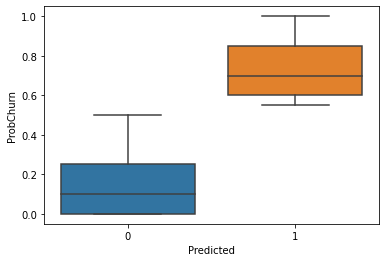

In [217]:
sns.boxplot(data = test, x = 'Predicted',y='ProbChurn')
test.groupby(by = 'Predicted')['ProbChurn'].max()

In [174]:
def get_classification_report(df):
    for lab,row in df.iterrows():
        if df.loc[lab,'Predicted'] == df.loc[lab,'Churn']:
            if df.loc[lab,'Predicted'] == 1:
                df.loc[lab,'TP'] = 1
            else:
                df.loc[lab,'TN'] = 1
        elif df.loc[lab,'Predicted'] != df.loc[lab,'Churn']:
            if df.loc[lab,'Predicted'] == 1:
                df.loc[lab,'FP'] = 1
            else:
                df.loc[lab,'FN'] = 1
    df = df.fillna(0)
    
    TN = df['TN'].sum()
    TP = df['TP'].sum()
    FN = df['FN'].sum()
    FP = df['FP'].sum()
    
    Precision = TP/(TP+FP)
    Accuracy = (TN+TP)/(TN+TP+FN+FP)
    Recall = TP/(TP+FN)
    Specificity = TN/(FP+TN)
    
    print(f'Precision: {Precision}')
    print(f'Accuracy: {Accuracy}')
    print(f'Specificity: {Specificity}')
    print(f'Recall: {Recall}')
    return df


In [175]:
test = get_classification_report(test)

Precision: 0.7117794486215538
Accuracy: 0.8195
Specificity: 0.9217687074829932
Recall: 0.5358490566037736


# Model Performance Analysis with BaseThreshold

#### Specificity
If a customer did not churn the model assigns them correcctly 92% of the time

#### Recall
If a customer did churn the model assigns them correctly 55% of the time

#### Precision
We correctly predict churn 70% of the time, given the context of the problem we actually prefer a little bit of a drop in precision if recall can be improved. 

#### Accuracy 
We get a customer's churn prediction correct about 83% of the time, but we suffer in a very low recall

#### Overall Performance
The model struggles to determine who will churn, but does a great job at predicting who will not churn. In the production setting the model will perform very well as a churn risk indicator, but will not be able to be used to accurately predict whether someone will churn.

In [208]:
def classification(df):
    df['TN'] = 0
    df['TP'] = 0
    df['FN'] = 0
    df['FP'] = 0
    
    for lab,row in df.iterrows():
        if df.loc[lab,'Predicted'] == df.loc[lab,'Churn']:
            if df.loc[lab,'Predicted'] == 1:
                df.loc[lab,'TP'] = 1
            else:
                df.loc[lab,'TN'] = 1
        #Given the predicted value does not equal the actual
        elif df.loc[lab,'Predicted'] != df.loc[lab,'Churn']:
            #False Positive if predicted is positive
            if df.loc[lab,'Predicted'] == 1:
                df.loc[lab,'FP'] = 1
            #False Negatice if predicted is negative
            else:
                df.loc[lab,'FN'] = 1
    
    return df.fillna(0)

def predict_churn(df,threshold):
    for lab,row in df.iterrows():
        #print(threshold)
        #print(df.loc[lab,'ProbChurn'])
        if df.loc[lab,'ProbChurn'] >= threshold:
            df.loc[lab,'Predicted'] = 1
        elif df.loc[lab,'ProbChurn'] < threshold:
            df.loc[lab,'Predicted'] = 0
        
    return classification(df)

def calc_metrics(df,threshold):
    TN = df['TN'].sum()
    TP = df['TP'].sum()
    FN = df['FN'].sum()
    FP = df['FP'].sum()

    Precision = TP/(TP+FP)
    Accuracy = (TN+TP)/(TN+TP+FN+FP)
    Recall = TP/(TP+FN)
    Specificity = TN/(FP+TN)
    #Print statement to aid visualization in debugging
    #print('Threshold',round(threshold,3))
    #print(f'Precision: {Precision}')
    #print(f'Accuracy: {Accuracy}')
    #print(f'Specificity: {Specificity}')
    #print(f'Recall: {Recall}')
    
    return [Precision,Accuracy,Recall,Specificity]
        
def get_threshold_report(df):
    metrics = []
    for threshold in np.arange(.2,.6,.1):
        df = predict_churn(df,threshold)
        #Print statement to aid visualization in debugging
        #print(threshold)
        #print(df[['ProbChurn','Predicted','Churn','TN','TP','FN','FP']])
        metrics.append([round(threshold,3),calc_metrics(df,threshold)])
    return metrics

In [209]:
df = {
    "Threshold":[],
    "Precision":[],
    "Accuracy":[],
    "Recall":[],
    "Specificity":[]
}
threshold_df = test.copy(deep = True)
for i in get_threshold_report(threshold_df):
    df["Threshold"].append(i[0])
    df["Precision"].append(i[1][0])
    df["Accuracy"].append(i[1][1])
    df["Recall"].append(i[1][2])
    df["Specificity"].append(i[1][3])
    
df = pd.DataFrame(df)

## Threshold Analysis

In [210]:
df.sort_values(by = 'Accuracy')

,Threshold,Precision,Accuracy,Recall,Specificity
0,0.2,0.478564,0.7135,0.905660,0.644218
1,0.3,0.598507,0.8010,0.756604,0.817007
2,0.4,0.662109,0.8180,0.639623,0.882313
3,0.5,0.711779,0.8195,0.535849,0.921769


In [211]:
analyze = predict_churn(threshold_df,.2)

<AxesSubplot:xlabel='MonthlyCharge', ylabel='Count'>

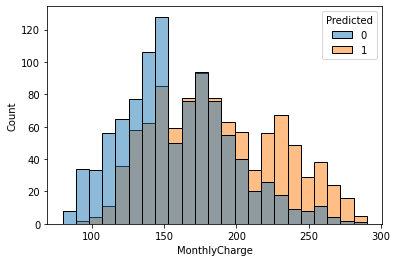

In [228]:
sns.histplot(data = analyze, x = 'MonthlyCharge',hue = 'Predicted')

<AxesSubplot:xlabel='Tenure', ylabel='Count'>

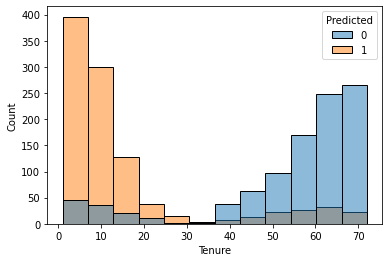

In [227]:
sns.histplot(data = analyze, x = 'Tenure',hue = 'Predicted')

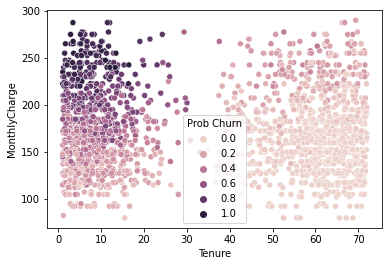

In [235]:
sns.scatterplot(data = analyze, x = 'Tenure',y = 'MonthlyCharge',hue = 'ProbChurn')
plt.legend(title = 'Prob Churn',loc = 'lower center')
plt.show()

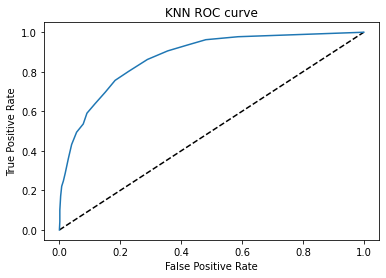

0.872518290335002


In [245]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr, tpr, thresholds = roc_curve(analyze['Churn'],analyze['ProbChurn'])
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr,label = 'KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC curve')
plt.show()
print(roc_auc_score(analyze['Churn'],analyze['ProbChurn']))

In [246]:
list(thresholds).index(.2)

17

In [249]:
FPR = fpr[17]
TPR = tpr[17]
FPR

0.35578231292517004

In [251]:
print(roc_auc_score(analyze['Churn'],analyze['ProbChurn'],max_fpr = FPR))

0.8096369435308894


In [248]:
1/2 - FPR/2 + TPR/2

0.7749390322166603

In [253]:
from sklearn.metrics import classification_report
print('.5 Threshold',classification_report(test['Churn'],test['Predicted']))
print('.2 Threshold',classification_report(analyze['Churn'],analyze['Predicted']))

.5 Threshold               precision    recall  f1-score   support

           0       0.85      0.92      0.88      1470
           1       0.71      0.54      0.61       530

    accuracy                           0.82      2000
   macro avg       0.78      0.73      0.75      2000
weighted avg       0.81      0.82      0.81      2000

.2 Threshold               precision    recall  f1-score   support

           0       0.95      0.64      0.77      1470
           1       0.48      0.91      0.63       530

    accuracy                           0.71      2000
   macro avg       0.71      0.77      0.70      2000
weighted avg       0.82      0.71      0.73      2000



In [184]:
def classify(df):
    #adds classification column to show how the record was classified
    x = ['FN','FP','TP','TN']
    for lab,row in df.iterrows():
        for i in x:
            if (df.loc[lab,'ProbChurn'] <= .3):
                df.loc[lab,'Risk'] = 'Slight'
            elif (df.loc[lab,'ProbChurn'] > .3) & (df.loc[lab,'ProbChurn'] < .4):
                df.loc[lab,'Risk'] = 'Medium'
            elif (df.loc[lab,'ProbChurn'] >= .4) & (df.loc[lab,'ProbChurn'] <= .5):
                df.loc[lab,'Risk'] = 'High'
            elif(df.loc[lab,'ProbChurn'] > .5):
                df.loc[lab,'Risk'] = 'Very High'
            elif df.loc[lab,i] == 1:
                df.loc[lab,'Classification'] = i
                continue
    return df

analyze = classify(analyze)
test = classify(test)

### Churn Notes

Churn rate is 26.5% in the test set

Threshold for Churn prediction is .2

The model performs much better at predicting customers who stay with the company.

    Precision for customers who do not churn .95
        Recall: .64 
        
    Precision for customers who do churn .48
        Recall: .91
        
    Overall Accuracy: .71